In [1]:
import matplotlib.pyplot as plt
import mediapy
import numpy as np
import torch
from PIL import Image
from torchvision import transforms as T

from comit import COMiT
from comit.utils import to_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Communication-Inspired Tokenization for Structured Image Representations

This notebook is designed to support the codebase of the paper "Communication-Inspired Tokenization for Structured Image Representations" that introduces COMiT -- a novel framework that learns structured, semantically meaningful discrete token sequences by combining attentive sequential tokenization process with semantic alignment. Here we demonstrate how to use pretrained COMiT variants to tokenize and detokenize images.

### Loading the pretrained checkpoints

First, one need to download and load the pretrained model. This can be done effectively from the Hugging Face Hub with just a few lines of code. 

In [2]:
model = COMiT.from_pretrained("cvg-unibe/comit-xl")
model.eval().to(device)
print("Model loaded successfully!")

/home/ad20n980/.conda/envs/comit/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Model loaded successfully!


### Tokenizing images

We start by loading a example image. We then resize it to $256\times 256$ resolution (native for COMiT) and normalize it to the range $[-1, 1]$.

""

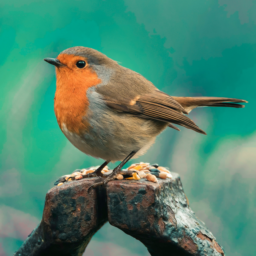

In [3]:
image_path = "../assets/bird.jpg"
sample = Image.open(image_path).convert("RGB")

transform = T.Compose([
    T.CenterCrop(min(sample.size)),
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
sample = transform(sample)
mediapy.show_image(to_image(sample))

We then construct a minibatch and move it to the model's device.

In [4]:
batch = torch.stack([sample], dim=0).to(device)
batch.shape

torch.Size([1, 3, 256, 256])

To tokenize the image, one simply needs to call the `tokenize` method of COMiT. It supports various cropping policies (see the paper) via three arguments:

1. `global_crop: bool`: If `True`, the first observation is the global crop or the original image as a whole.
2. `order: str | list[int] | list[list[int]]`: One of ["raster_scan", "random", "adaptive"] or an explicit list of crop indices in a uniform $3\times 3$ grid in the raster scan order (can be specified per batch element, in which case the [i, j]-th elemnet of the order list is the index of the ith crop for the jth minibatch sample)
3. `num_crops: int`: Used to truncate the list of crops after reordering.

In [5]:
with torch.no_grad():
    token_dict = model.tokenize(
        batch,
        global_crop=False,
        order="adaptive",
        num_crops=3,
    )

With the above code, the tokenization pipeline automatically selects three local crops to embed.

The output `token_dict` contains the latent messages and the offsets with respect to the last observed crop (needed for decoding).

In [6]:
print("Latent messages:", token_dict["msgs"].shape)
print("Offsets:", token_dict["offsets"].shape)

Latent messages: torch.Size([1, 256, 6])
Offsets: torch.Size([1, 2])


By default `tokenize` returns the latent messages in a form of a sequence of 6-dimensional vectors. If the token indices are needed instead, those can be obtained with the following.

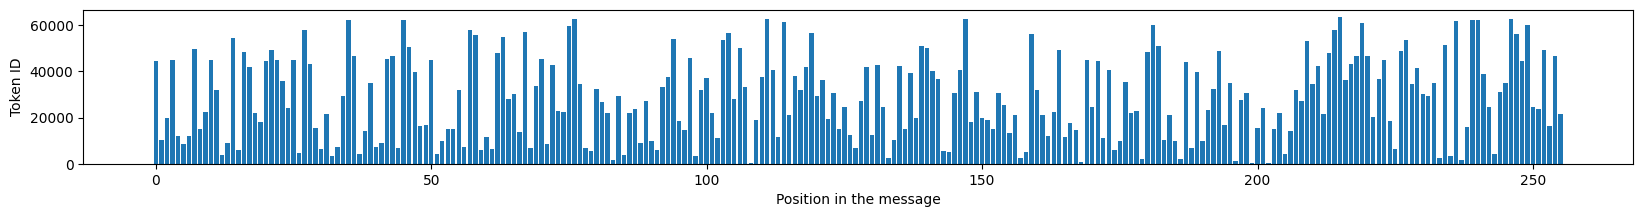

In [7]:
token_ids = model.quantizer.codes_to_indices(token_dict["msgs"]).cpu()

# Visualize the message as a bar plot
plt.figure(figsize=(20, 2))
plt.bar(np.arange(256), token_ids[0])
plt.ylabel("Token ID")
plt.xlabel("Position in the message")
plt.show()

### Detokenizing images

The detokenization is done by feeding the messages and the offsets to the `detokenize` method.

GT,Reconstructed

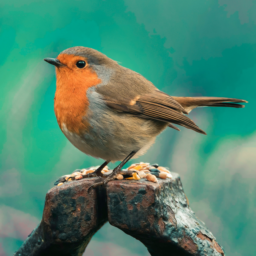
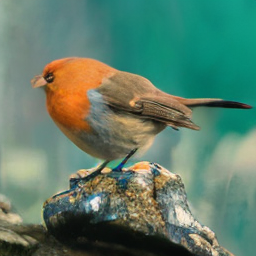

In [9]:
with torch.no_grad():
    detoken_dict = model.detokenize(
        msgs=token_dict["msgs"],
        offsets=token_dict["offsets"],
        num_steps=10,  # Number of denoising steps
        odesolver="euler",  # The numerical velocity field integration method
        cfg_weight=7.5,  # CFG strength
    )

# Display the reconstruction
mediapy.show_images([to_image(sample), to_image(detoken_dict["generated"][0])], titles=["GT", "Reconstructed"])

Note that because we used only three crops, the reconstruction cannot match the original input image. However, it can be seen that the obtained message captures the overall semantics of the image (such that the object categories). If global reconstruction is important for the downstream usage, it is recommended to use the global crop for tokenization.

For visually probing the information in the messages, it is better to avoid full generation, as it may hallucinate missing information. Instead, one-step generation with no CFG results in images with sharp details within the observed content and blurry regions outside.

GT,Reconstructed

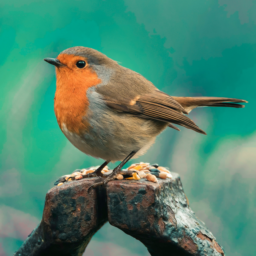
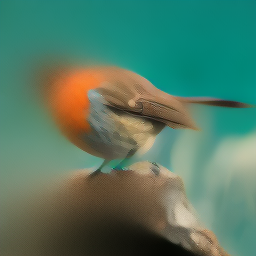

In [10]:
with torch.no_grad():
    detoken_dict = model.detokenize(
        msgs=token_dict["msgs"],
        offsets=token_dict["offsets"],
        num_steps=1,
        odesolver="euler",
        cfg_weight=1.0,
    )

# Display the reconstruction
mediapy.show_images([to_image(sample), to_image(detoken_dict["generated"][0])], titles=["GT", "Reconstructed"])

Note that the offsets ground the content globally, so changing them results in a global shift in the reconstructed images.

GT,Reconstructed

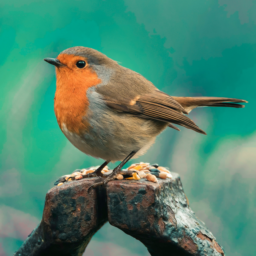
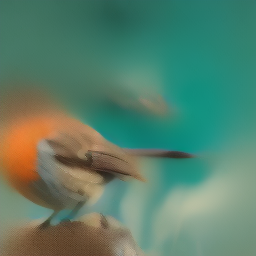

In [11]:
with torch.no_grad():
    detoken_dict = model.detokenize(
        msgs=token_dict["msgs"],
        offsets=token_dict["offsets"] + torch.tensor([[0.4, -0.4]]).to(device),
        num_steps=1,
        odesolver="euler",
        cfg_weight=1.0,
    )

# Display the reconstruction
mediapy.show_images([to_image(sample), to_image(detoken_dict["generated"][0])], titles=["GT", "Reconstructed"])

For convenience, we also provide the `reconstruct` method that pipelines `tokenize` and `detokenize` into a single call.

GT,Reconstructed

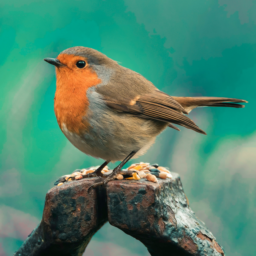
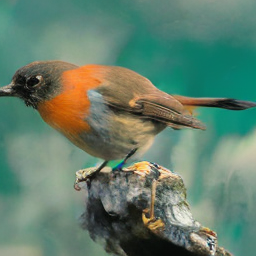

In [13]:
with torch.no_grad():
    rec_dict = model.reconstruct(
        batch,
        global_crop=False,
        order="adaptive",
        num_crops=3,
        num_steps=10,
        odesolver="euler",
        cfg_weight=7.5,
    )

# Display the reconstruction
mediapy.show_images([to_image(sample), to_image(rec_dict["generated"][0])], titles=["GT", "Reconstructed"])

We also may directly specify the order of crops to capture more relevant parts of the image.

GT,Reconstructed

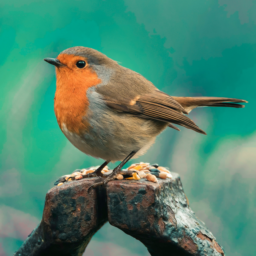
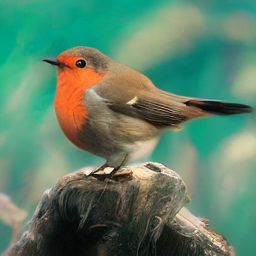

In [26]:
with torch.no_grad():
    rec_dict = model.reconstruct(
        batch,
        global_crop=False,
        order=[5, 6, 8, 4, 0],
        num_steps=10,
        odesolver="euler",
        cfg_weight=7.5,
    )

# Display the reconstruction
mediapy.show_images([to_image(sample), to_image(rec_dict["generated"][0])], titles=["GT", "Reconstructed"])